In [118]:
import pandas as pd
from pycaret.classification import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from imblearn.combine import SMOTEENN
import optunahub
import optuna

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [124]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_mid = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [3]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


## GK


### Base Model


In [4]:
g_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[g_cs_features]
g_cs_data_tar = g_cs_data_tar[g_cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

clean_sheets
0    1231
1     381
Name: count, dtype: int64


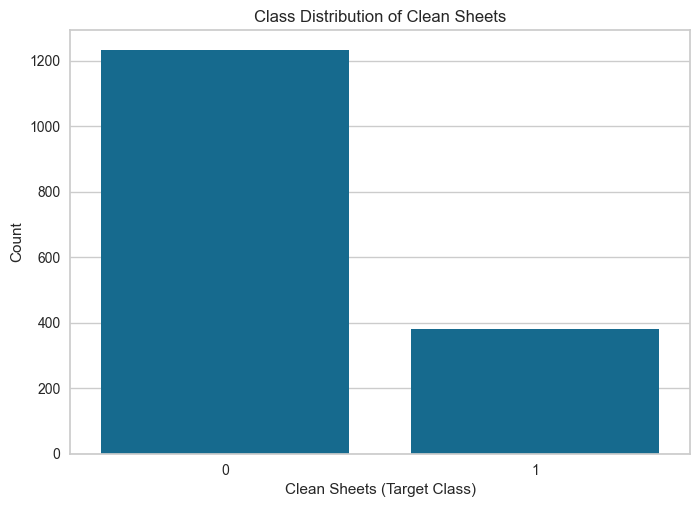

In [5]:
print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

In [6]:
base_g_cs_model = setup(g_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_cs_best = base_g_cs_model.compare_models(sort='AUC')
base_g_cs_best

[LightGBM] [Info] Number of positive: 984, number of negative: 984
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11346
[LightGBM] [Info] Number of data points in the train set: 1968, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3092
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(2291, 24)"
5,Transformed train set shape,"(1968, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5958,0.5905,0.5216,0.2974,0.3782,0.1111,0.1212,1.3340
lightgbm,Light Gradient Boosting Machine,0.7347,0.5903,0.1477,0.3652,0.2058,0.0805,0.0945,1.8680
ridge,Ridge Classifier,0.5749,0.5845,0.5184,0.2834,0.3652,0.0864,0.0955,0.4670
lr,Logistic Regression,0.5788,0.5812,0.5151,0.2845,0.3662,0.0887,0.0976,4.7330
et,Extra Trees Classifier,0.7277,0.5708,0.1219,0.3112,0.1741,0.0475,0.0552,1.5660
xgboost,Extreme Gradient Boosting,0.7238,0.5632,0.1549,0.3318,0.2102,0.0685,0.0766,1.4170
nb,Naive Bayes,0.4941,0.5458,0.6066,0.2589,0.3625,0.0460,0.0563,1.4050
knn,K Neighbors Classifier,0.4918,0.5413,0.6106,0.2579,0.3624,0.0446,0.0563,1.7110
rf,Random Forest Classifier,0.7301,0.5408,0.1120,0.3192,0.1633,0.0439,0.0543,1.0220
qda,Quadratic Discriminant Analysis,0.5492,0.5399,0.4688,0.2546,0.3298,0.0334,0.0369,1.1200


LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

In [7]:
evaluate_model(base_g_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

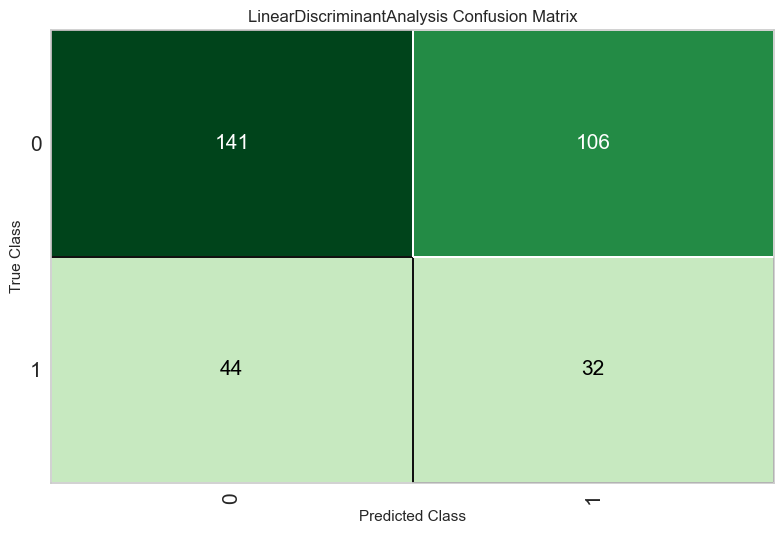

In [8]:
plot_model(base_g_cs_best, plot='confusion_matrix')

### Tuned Model


In [9]:
# Enhanced setup for better performance
tuned_g_cs_model = setup(g_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_cs_best = tuned_g_cs_model.compare_models(n_select=3, sort='F1')
g_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(835, 59)"
5,Transformed train set shape,"(534, 59)"
6,Transformed test set shape,"(323, 59)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.3521,0.5067,0.7957,0.2386,0.3536,0.0046,0.0178,0.2950
dummy,Dummy Classifier,0.2901,0.5000,0.9000,0.2134,0.3449,0.0000,0.0000,0.3580
svm,SVM - Linear Kernel,0.5407,0.5228,0.5020,0.2573,0.3383,0.0402,0.0468,0.3400
lr,Logistic Regression,0.5718,0.5412,0.4555,0.2637,0.3323,0.0493,0.0547,0.3610
lda,Linear Discriminant Analysis,0.5563,0.5251,0.4663,0.2595,0.3316,0.0402,0.0438,0.4360
ridge,Ridge Classifier,0.5625,0.5270,0.4526,0.2561,0.3262,0.0373,0.0414,0.3300
knn,K Neighbors Classifier,0.4763,0.4981,0.5206,0.2294,0.3181,-0.0134,-0.0142,0.3470
dt,Decision Tree Classifier,0.5865,0.5152,0.3801,0.2536,0.3033,0.0268,0.0275,0.3290
gbc,Gradient Boosting Classifier,0.6532,0.5527,0.3051,0.2908,0.2965,0.0679,0.0677,0.5920
ada,Ada Boost Classifier,0.5982,0.5220,0.3406,0.2486,0.2861,0.0176,0.0175,0.4630


[GaussianNB(priors=None, var_smoothing=1e-09),
 DummyClassifier(constant=None, random_state=123, strategy='prior'),
 SGDClassifier(alpha=0.0001, average=False, class_weight=None,
               early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
               l1_ratio=0.15, learning_rate='optimal', loss='hinge',
               max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
               power_t=0.5, random_state=123, shuffle=True, tol=0.001,
               validation_fraction=0.1, verbose=0, warm_start=False)]

In [10]:
# Ensemble (blend or stack)
g_cs_blended = blend_models(g_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2791,0.0000,0.9667,0.2397,0.3841,0.0182,0.0655
1,0.2713,0.0000,0.8667,0.2241,0.3562,-0.0212,-0.0595
2,0.2791,0.0000,1.0000,0.2439,0.3922,0.0291,0.1216
3,0.4574,0.0000,0.7333,0.2619,0.3860,0.0658,0.0949
4,0.3333,0.0000,0.9032,0.2523,0.3944,0.0299,0.0694
5,0.2636,0.0000,0.9355,0.2377,0.3791,-0.0067,-0.0255
6,0.2636,0.0000,0.9355,0.2377,0.3791,-0.0067,-0.0255
7,0.2791,0.0000,0.9355,0.2417,0.3841,0.0035,0.0116
8,0.5426,0.0000,0.6129,0.2879,0.3918,0.0962,0.1140


In [11]:
g_cs_tuned = tune_model(g_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2791,0.0000,0.9667,0.2397,0.3841,0.0182,0.0655
1,0.2558,0.0000,0.8333,0.2155,0.3425,-0.0430,-0.1205
2,0.2636,0.0000,1.0000,0.2400,0.3871,0.0192,0.0985
3,0.7519,0.0000,0.0000,0.0000,0.0000,-0.0299,-0.0691
4,0.7132,0.0000,0.0968,0.2500,0.1395,0.0062,0.0073
5,0.6357,0.0000,0.0968,0.1364,0.1132,-0.1078,-0.1103
6,0.3023,0.0000,0.9677,0.2521,0.4000,0.0302,0.0952
7,0.2481,0.0000,0.9032,0.2295,0.3660,-0.0279,-0.1055
8,0.6822,0.0000,0.1613,0.2500,0.1961,0.0094,0.0097


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


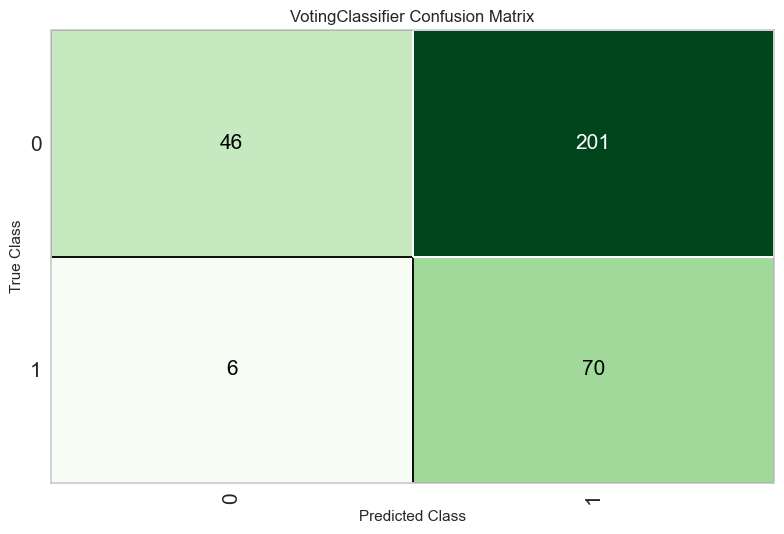

In [12]:
plot_model(g_cs_tuned, plot='confusion_matrix')

In [13]:
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_cs_tuned, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.3591,0.5536,0.9211,0.2583,0.4035,0.0568,0.1238


In [14]:
# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [15]:
evaluate_model(g_cs_tuned)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [16]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [17]:
g_cs_final_model = finalize_model(g_cs_tuned)


In [18]:
save_model(g_cs_final_model, './models/g_cs_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                              early_stopping=False,
                  

### Predictions


Transformation Pipeline and Model Successfully Loaded


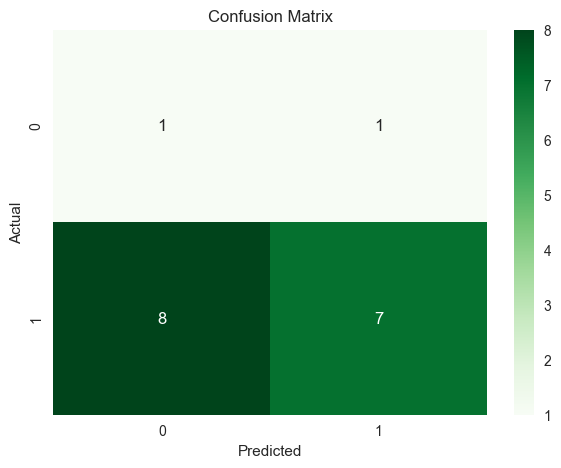

Transformation Pipeline and Model Successfully Loaded


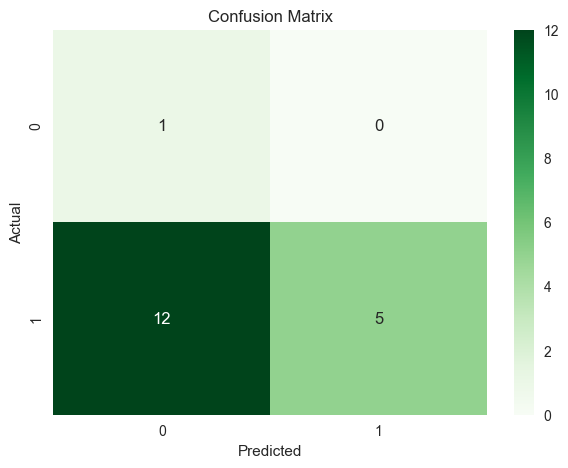

Transformation Pipeline and Model Successfully Loaded


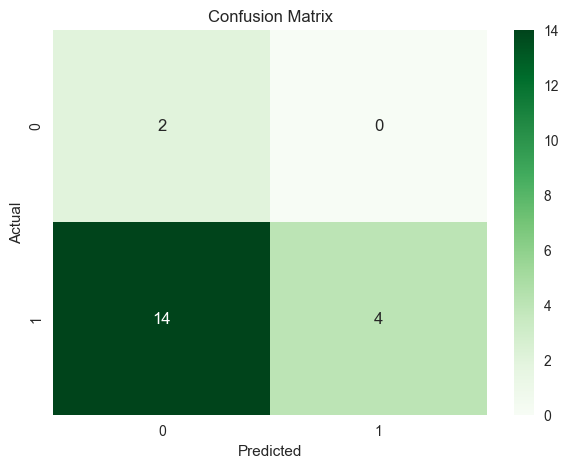

In [119]:
data_36_gk_cs = data_36_gk[g_cs_features]
data_37_gk_cs = data_37_gk[g_cs_features]
data_38_gk_cs = data_38_gk[g_cs_features]


data_36_gk_cs.reset_index(drop=True, inplace=True)
g_cs = data_36_gk_cs[['clean_sheets']].copy()
data_36_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)
g_cs_model = load_model('./models/g_cs_final_model')
g_cs_preds_36 = predict_model(g_cs_model, data=data_36_gk_cs)
g_cs_preds_36 = g_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(g_cs_preds_36['cs_preds'], g_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_gk_cs.reset_index(drop=True, inplace=True)
g_cs = data_37_gk_cs[['clean_sheets']].copy()
data_37_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)
g_cs_model = load_model('./models/g_cs_final_model')
g_cs_preds_37 = predict_model(g_cs_model, data=data_37_gk_cs)
g_cs_preds_37 = g_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(g_cs_preds_37['cs_preds'], g_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_gk_cs.reset_index(drop=True, inplace=True)
g_cs = data_38_gk_cs[['clean_sheets']].copy()
data_38_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)
g_cs_model = load_model('./models/g_cs_final_model')
g_cs_preds_38 = predict_model(g_cs_model, data=data_38_gk_cs)
g_cs_preds_38 = g_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(g_cs_preds_38['cs_preds'], g_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Def


In [19]:
d_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[d_cs_features]
def_cs_data_tar = def_cs_data_tar[d_cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


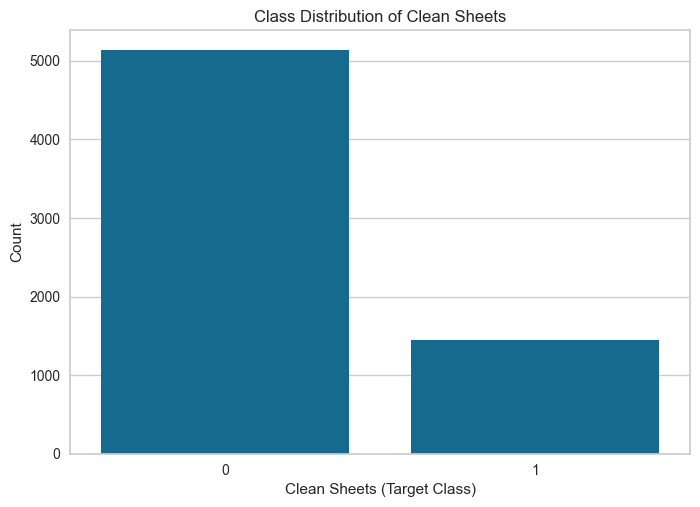

In [20]:
print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [21]:
base_def_cs_model = setup(def_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_cs_best = base_def_cs_model.compare_models(sort='AUC')
base_def_cs_best

[LightGBM] [Info] Number of positive: 4104, number of negative: 4104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16938
[LightGBM] [Info] Number of data points in the train set: 8208, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3089
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(9523, 24)"
5,Transformed train set shape,"(8208, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8473,0.8553,0.4480,0.7604,0.5624,0.4774,0.5027,3.5580
rf,Random Forest Classifier,0.8404,0.8319,0.3276,0.8623,0.4726,0.4006,0.4669,4.5000
xgboost,Extreme Gradient Boosting,0.8273,0.8126,0.3527,0.7215,0.4702,0.3820,0.4184,3.3300
lightgbm,Light Gradient Boosting Machine,0.8094,0.7805,0.2124,0.7260,0.3278,0.2540,0.3200,5.3100
knn,K Neighbors Classifier,0.5778,0.6982,0.7366,0.3074,0.4335,0.1795,0.2239,2.6570
gbc,Gradient Boosting Classifier,0.7839,0.6698,0.0581,0.5981,0.1047,0.0679,0.1315,8.2630
lda,Linear Discriminant Analysis,0.6008,0.6261,0.5598,0.2889,0.3809,0.1287,0.1442,3.8910
ridge,Ridge Classifier,0.6006,0.6238,0.5572,0.2888,0.3800,0.1278,0.1427,2.1990
lr,Logistic Regression,0.5997,0.6233,0.5624,0.2892,0.3815,0.1291,0.1447,4.6310
ada,Ada Boost Classifier,0.7347,0.6175,0.2019,0.3334,0.2493,0.1005,0.1060,3.1310


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=3089, verbose=0,
                     warm_start=False)

In [22]:
evaluate_model(base_def_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [23]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_def_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8745,0.8927,0.5521,0.8154,0.6584,0.5850,0.6017


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
3828,0.295,0.255,0.450,False,2,2,3257.0,0.751825,2.4,18.200001,...,1.2,2.4,0.4,0.37,0.35,-0.18,0,0,0.71,0.29
1788,0.241,0.235,0.523,False,5,3,0.0,-0.140902,3.0,19.400000,...,1.0,1.6,2.6,0.58,0.52,2.66,0,0,0.54,0.46
4515,0.887,0.072,0.041,True,2,5,64356.0,0.426599,4.7,20.200001,...,1.6,1.6,3.8,0.86,0.79,5.50,0,0,0.74,0.26
5790,NaN,NaN,NaN,True,4,2,3540.0,0.382425,1.2,10.600000,...,0.8,1.0,3.8,0.09,0.09,2.06,0,0,0.87,0.13
2659,0.796,0.125,0.078,True,2,5,159254.0,0.769577,5.7,13.000000,...,2.0,1.4,7.4,0.91,0.71,11.54,1,1,0.24,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,0.652,0.211,0.136,True,2,2,-3685.0,0.411311,0.0,0.000000,...,1.0,0.8,2.8,0.18,0.18,2.54,1,0,0.90,0.10
6319,NaN,NaN,NaN,True,3,4,0.0,0.949155,3.0,16.200001,...,1.2,1.6,4.6,0.62,0.35,2.98,1,1,0.49,0.51
981,0.771,0.157,0.072,True,2,3,-89637.0,-0.978299,4.2,12.400000,...,1.6,2.4,2.6,0.30,0.28,4.58,0,1,0.49,0.51
744,0.336,0.269,0.395,True,3,4,-55520.0,-0.870907,10.4,22.400000,...,1.8,2.8,2.8,0.38,0.18,2.84,0,0,0.90,0.10


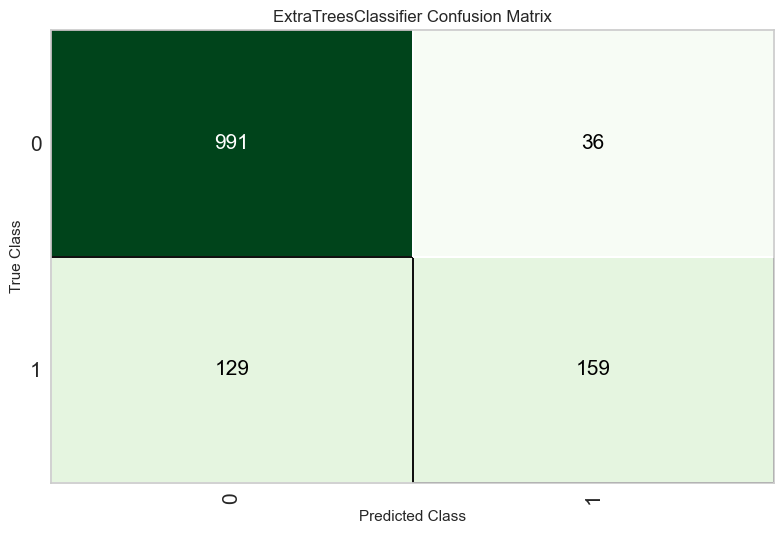

In [24]:
plot_model(base_def_cs_best, plot='confusion_matrix')

In [25]:
base_def_cs_tuned = tune_model(base_def_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5703,0.6249,0.5217,0.2597,0.3468,0.0775,0.0880
1,0.6293,0.6481,0.5043,0.2959,0.3730,0.1345,0.1441
2,0.5951,0.5927,0.4783,0.2644,0.3406,0.0821,0.0896
3,0.6122,0.6043,0.5652,0.2968,0.3892,0.1437,0.1597
4,0.5875,0.6285,0.5517,0.2795,0.3710,0.1106,0.1248
5,0.6122,0.6327,0.5690,0.3000,0.3929,0.1463,0.1625
6,0.6065,0.6266,0.5086,0.2823,0.3631,0.1109,0.1210
7,0.6407,0.6506,0.5259,0.3128,0.3923,0.1600,0.1708
8,0.5943,0.6049,0.4957,0.2689,0.3486,0.0902,0.0991


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [26]:
save_model(base_def_cs_tuned, './models/def_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned Model


In [27]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_def_cs_model = setup(def_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_cs_best = tuned_def_cs_model.compare_models(n_select=3, sort='F1')
def_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(4383, 65)"
5,Transformed train set shape,"(3156, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.6987,0.6905,0.4773,0.3598,0.4091,0.2127,0.2173,1.0810
lda,Linear Discriminant Analysis,0.5302,0.6311,0.7226,0.2794,0.4028,0.1265,0.1665,0.8500
ridge,Ridge Classifier,0.5202,0.6318,0.7286,0.2753,0.3994,0.1190,0.1600,1.0940
lr,Logistic Regression,0.5261,0.6294,0.7113,0.2754,0.3969,0.1180,0.1550,1.0690
lightgbm,Light Gradient Boosting Machine,0.7296,0.6910,0.4029,0.3890,0.3950,0.2213,0.2217,2.6760
rf,Random Forest Classifier,0.7155,0.6800,0.4046,0.3659,0.3833,0.1994,0.2003,2.0190
dt,Decision Tree Classifier,0.6438,0.5936,0.5042,0.3088,0.3826,0.1522,0.1616,1.7030
xgboost,Extreme Gradient Boosting,0.7216,0.6804,0.3916,0.3731,0.3811,0.2021,0.2026,1.2730
knn,K Neighbors Classifier,0.4108,0.5984,0.8032,0.2440,0.3743,0.0568,0.0963,1.1190
svm,SVM - Linear Kernel,0.5097,0.5911,0.6603,0.2592,0.3715,0.0827,0.1069,1.1060


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001),
 RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_state=123, solver='auto',
                 tol=0.0001)]

In [28]:
# Ensemble (blend or stack)
def_cs_blended = blend_models(def_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5114,0.0000,0.7586,0.2776,0.4065,0.1234,0.1695
1,0.5437,0.0000,0.7586,0.2933,0.4231,0.1540,0.2023
2,0.5266,0.0000,0.7759,0.2875,0.4196,0.1442,0.1959
3,0.5475,0.0000,0.6810,0.2821,0.3990,0.1266,0.1585
4,0.5437,0.0000,0.7739,0.2937,0.4258,0.1594,0.2118
5,0.5437,0.0000,0.5652,0.2549,0.3514,0.0716,0.0851
6,0.5133,0.0000,0.6696,0.2610,0.3756,0.0890,0.1159
7,0.5209,0.0000,0.6522,0.2613,0.3731,0.0886,0.1132
8,0.5162,0.0000,0.7304,0.2736,0.3981,0.1165,0.1566


In [29]:
def_cs_tuned = tune_model(def_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5095,0.0000,0.7586,0.2767,0.4055,0.1217,0.1676
1,0.5095,0.0000,0.8190,0.2861,0.4241,0.1445,0.2070
2,0.4848,0.0000,0.7759,0.2687,0.3991,0.1063,0.1537
3,0.5437,0.0000,0.7414,0.2905,0.4175,0.1473,0.1916
4,0.5342,0.0000,0.8087,0.2943,0.4316,0.1633,0.2246
5,0.4962,0.0000,0.6261,0.2449,0.3521,0.0551,0.0715
6,0.5133,0.0000,0.6696,0.2610,0.3756,0.0890,0.1159
7,0.5228,0.0000,0.6522,0.2622,0.3741,0.0904,0.1152
8,0.5067,0.0000,0.7478,0.2722,0.3991,0.1147,0.1579


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


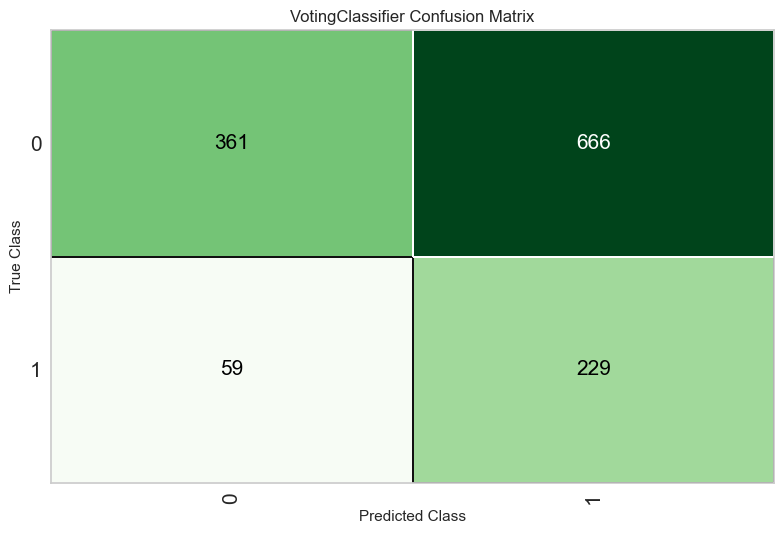

In [30]:
plot_model(def_cs_tuned, plot='confusion_matrix')

### Predictions


Transformation Pipeline and Model Successfully Loaded


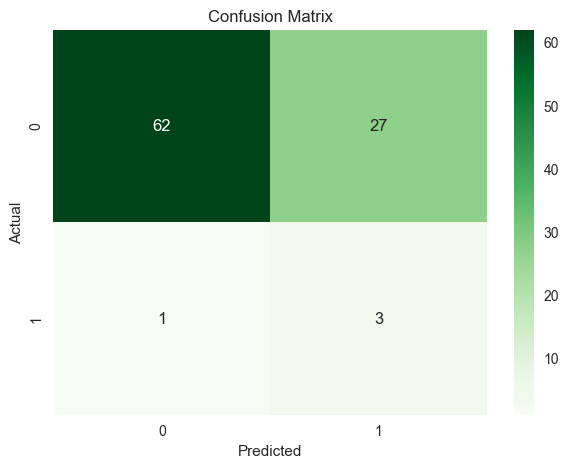

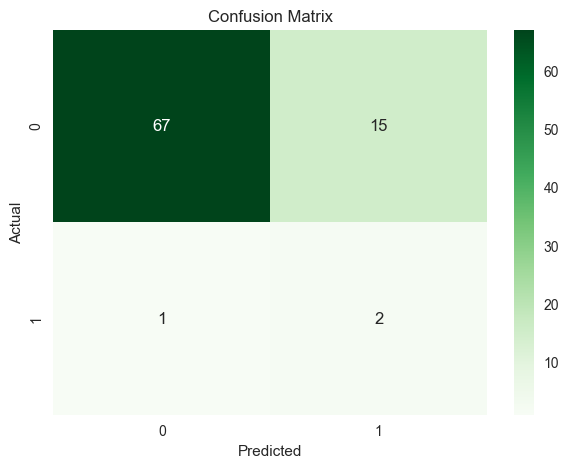

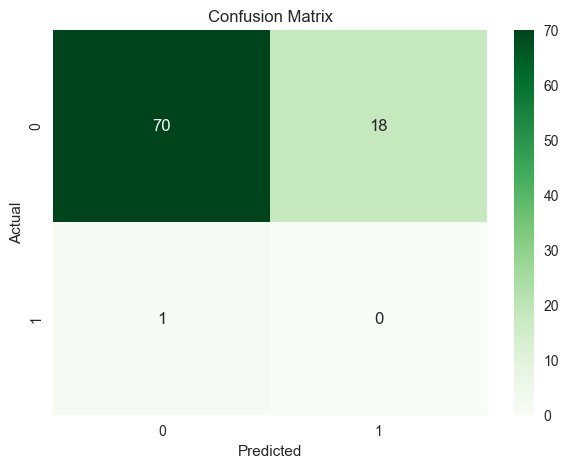

In [123]:
data_36_def_cs = data_36_def[d_cs_features]
data_37_def_cs = data_37_def[d_cs_features]
data_38_def_cs = data_38_def[d_cs_features]
# Load model
d_cs_model = load_model('./models/def_cs_final_model')


data_36_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_36 = predict_model(d_cs_model, data=data_36_def_cs)
d_cs_preds_36 = d_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_36['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_37 = predict_model(d_cs_model, data=data_37_def_cs)
d_cs_preds_37 = d_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_37['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_38 = predict_model(d_cs_model, data=data_38_def_cs)
d_cs_preds_38 = d_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_38['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Mid


In [31]:
mid_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[mid_cs_features]
mid_cs_data_tar = mid_cs_data_tar[mid_cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


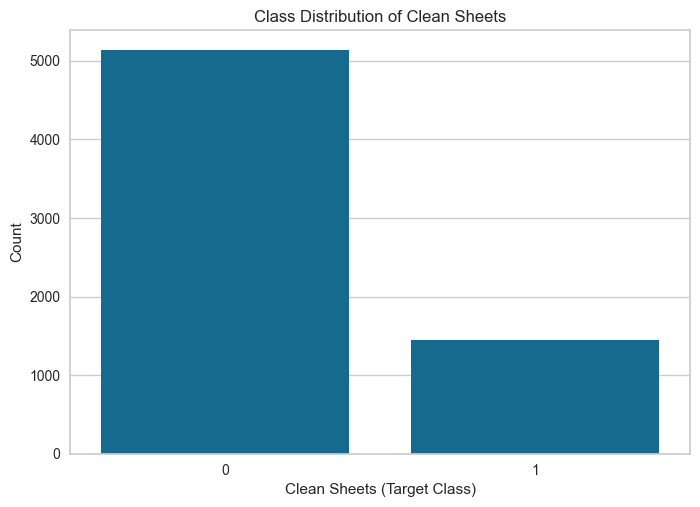

In [32]:
print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base


In [33]:
base_mid_cs_model = setup(mid_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_cs_best = base_mid_cs_model.compare_models(sort='AUC')
base_mid_cs_best

[LightGBM] [Info] Number of positive: 4104, number of negative: 4104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17236
[LightGBM] [Info] Number of data points in the train set: 8208, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,2073
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(9523, 24)"
5,Transformed train set shape,"(8208, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8581,0.8651,0.4671,0.8060,0.5899,0.5117,0.5402,2.9310
rf,Random Forest Classifier,0.8412,0.8377,0.3414,0.8396,0.4838,0.4097,0.4683,3.3940
xgboost,Extreme Gradient Boosting,0.8313,0.7987,0.3717,0.7253,0.4906,0.4022,0.4348,2.3020
lightgbm,Light Gradient Boosting Machine,0.8174,0.7834,0.2452,0.7564,0.3661,0.2927,0.3572,7.5860
knn,K Neighbors Classifier,0.5951,0.7348,0.7756,0.3240,0.4568,0.2132,0.2655,2.4170
gbc,Gradient Boosting Classifier,0.7826,0.6789,0.0641,0.5557,0.1134,0.0710,0.1274,4.3020
dt,Decision Tree Classifier,0.7425,0.6407,0.4592,0.4213,0.4389,0.2724,0.2731,2.3080
ridge,Ridge Classifier,0.6008,0.6259,0.5727,0.2917,0.3863,0.1348,0.1518,2.3420
lr,Logistic Regression,0.5949,0.6252,0.5744,0.2880,0.3833,0.1289,0.1462,2.6490
ada,Ada Boost Classifier,0.7322,0.6210,0.1984,0.3221,0.2435,0.0930,0.0975,2.8140


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=2073, verbose=0,
                     warm_start=False)

In [34]:
evaluate_model(base_mid_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [35]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_mid_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8548,0.8642,0.4688,0.7803,0.5857,0.5042,0.5283


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
6098,NaN,NaN,NaN,True,4,3,2782.0,0.153119,5.3,19.200001,...,1.6,2.2,0.4,0.13,0.13,0.18,0,0,0.76,0.24
4420,0.336,0.269,0.395,True,2,2,-2561.0,-0.481776,3.0,14.200000,...,1.4,1.8,3.4,0.16,0.15,2.00,0,0,0.78,0.22
5236,0.670,0.196,0.134,False,1,3,-1151.0,-0.138928,2.2,19.600000,...,1.6,1.2,1.8,0.24,0.24,0.62,1,0,0.67,0.33
5387,0.127,0.212,0.661,False,5,2,93885.0,0.844869,5.6,10.600000,...,1.0,2.2,3.0,0.46,0.37,2.74,0,0,0.63,0.37
1924,0.291,0.270,0.439,False,3,3,106448.0,0.269224,2.1,16.600000,...,1.2,1.6,4.8,0.25,0.24,3.64,1,1,0.22,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3196,0.582,0.222,0.196,False,2,3,-290.0,-0.289455,2.0,17.600000,...,0.8,1.6,2.2,0.31,0.31,1.96,0,0,0.66,0.34
3005,0.363,0.252,0.385,False,3,3,72004.0,0.699096,5.4,24.799999,...,3.0,0.6,2.0,0.44,0.33,1.98,0,0,0.59,0.41
5040,0.810,0.126,0.063,True,2,5,312988.0,0.866392,5.0,21.400000,...,2.2,1.4,6.0,0.73,0.64,4.00,1,1,0.44,0.56
3564,0.508,0.241,0.251,False,2,4,3260.0,0.027561,2.8,12.000000,...,1.6,1.8,4.0,0.17,0.17,3.36,0,0,0.69,0.31


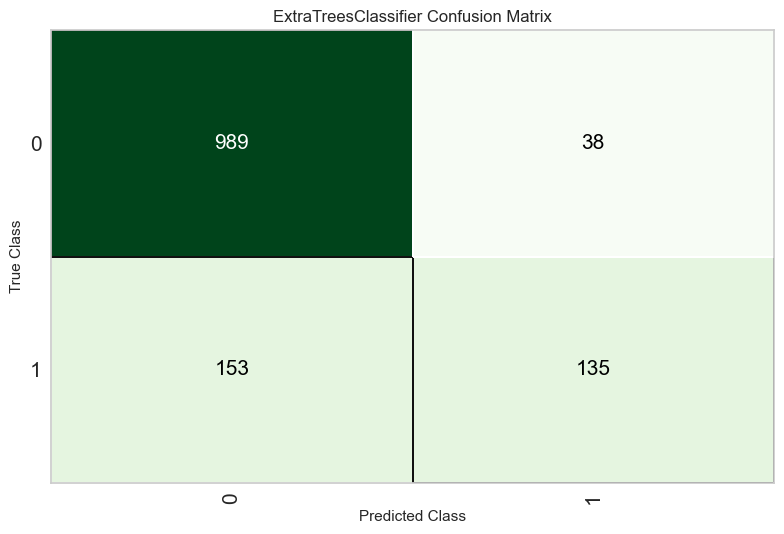

In [36]:

plot_model(base_mid_cs_best, plot='confusion_matrix')

In [37]:
base_mid_cs_tuned = tune_model(base_mid_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7795,0.7374,0.4483,0.5000,0.4727,0.3338,0.3346
1,0.7852,0.7502,0.4138,0.5161,0.4593,0.3273,0.3304
2,0.7586,0.7346,0.3966,0.4466,0.4201,0.2683,0.2691
3,0.7376,0.7196,0.3190,0.3854,0.3491,0.1866,0.1879
4,0.7471,0.7226,0.4174,0.4211,0.4192,0.2576,0.2576
5,0.7510,0.6771,0.3391,0.4149,0.3732,0.2198,0.2215
6,0.7414,0.7008,0.2870,0.3793,0.3267,0.1705,0.1731
7,0.7376,0.6992,0.4261,0.4050,0.4153,0.2463,0.2464
8,0.7657,0.6851,0.3304,0.4524,0.3819,0.2417,0.2462


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [38]:
save_model(base_mid_cs_best, './models/mid_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned


In [39]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_mid_cs_model = setup(mid_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_cs_best = tuned_mid_cs_model.compare_models(n_select=3, sort='F1')
mid_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(4499, 65)"
5,Transformed train set shape,"(3184, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7100,0.7020,0.4887,0.3765,0.4246,0.2353,0.2393,1.2110
lr,Logistic Regression,0.5242,0.6272,0.7174,0.2755,0.3979,0.1186,0.1570,0.8870
ridge,Ridge Classifier,0.5242,0.6273,0.7165,0.2755,0.3977,0.1184,0.1566,0.7410
lda,Linear Discriminant Analysis,0.5242,0.6285,0.7139,0.2746,0.3963,0.1167,0.1551,0.9680
xgboost,Extreme Gradient Boosting,0.7199,0.6820,0.4038,0.3727,0.3872,0.2062,0.2066,1.2750
knn,K Neighbors Classifier,0.4268,0.6107,0.8241,0.2528,0.3868,0.0767,0.1280,0.7600
dt,Decision Tree Classifier,0.6379,0.5914,0.5087,0.3050,0.3811,0.1473,0.1571,0.7950
rf,Random Forest Classifier,0.7140,0.6757,0.3995,0.3666,0.3808,0.1961,0.1970,1.4080
lightgbm,Light Gradient Boosting Machine,0.7227,0.6888,0.3796,0.3712,0.3751,0.1970,0.1972,3.3350
gbc,Gradient Boosting Classifier,0.6858,0.6591,0.4193,0.3328,0.3697,0.1651,0.1675,2.7860


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_

In [40]:
# Ensemble (blend or stack)
mid_cs_blended = blend_models(mid_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5171,0.0000,0.7586,0.2803,0.4093,0.1287,0.1753
1,0.5304,0.0000,0.7845,0.2907,0.4242,0.1510,0.2053
2,0.5095,0.0000,0.7328,0.2724,0.3972,0.1115,0.1512
3,0.5304,0.0000,0.6897,0.2749,0.3931,0.1136,0.1460
4,0.5266,0.0000,0.7913,0.2880,0.4223,0.1497,0.2058
5,0.4962,0.0000,0.6783,0.2549,0.3705,0.0773,0.1035
6,0.4943,0.0000,0.6870,0.2557,0.3726,0.0792,0.1069
7,0.5247,0.0000,0.6348,0.2598,0.3687,0.0847,0.1066
8,0.5295,0.0000,0.7130,0.2770,0.3990,0.1220,0.1594


In [41]:
mid_cs_tuned = tune_model(mid_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5266,0.0000,0.7672,0.2862,0.4169,0.1409,0.1904
1,0.5342,0.0000,0.7759,0.2913,0.4235,0.1514,0.2036
2,0.5076,0.0000,0.7672,0.2773,0.4073,0.1233,0.1712
3,0.5361,0.0000,0.6983,0.2793,0.3990,0.1226,0.1572
4,0.5456,0.0000,0.7913,0.2974,0.4323,0.1678,0.2247
5,0.5076,0.0000,0.6261,0.2500,0.3573,0.0652,0.0835
6,0.5152,0.0000,0.6435,0.2569,0.3672,0.0796,0.1020
7,0.5057,0.0000,0.6783,0.2591,0.3750,0.0857,0.1133
8,0.5257,0.0000,0.6870,0.2705,0.3882,0.1078,0.1394


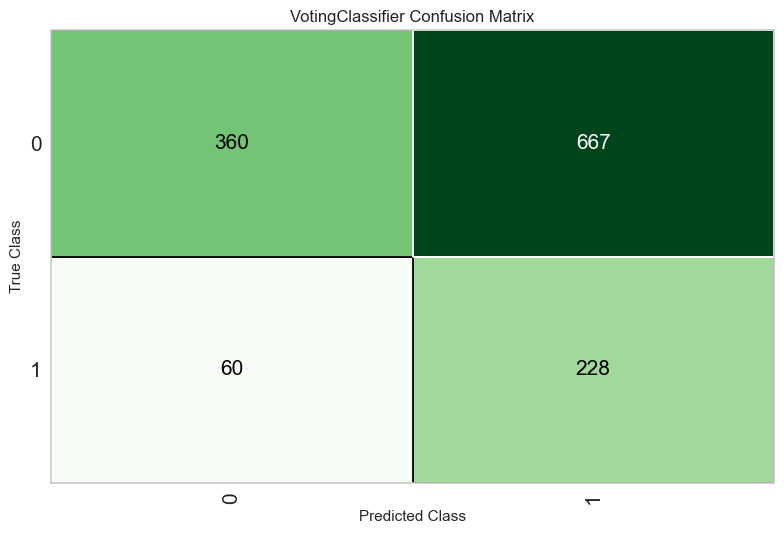

In [42]:
plot_model(mid_cs_tuned, plot='confusion_matrix')

### Predictions


Transformation Pipeline and Model Successfully Loaded


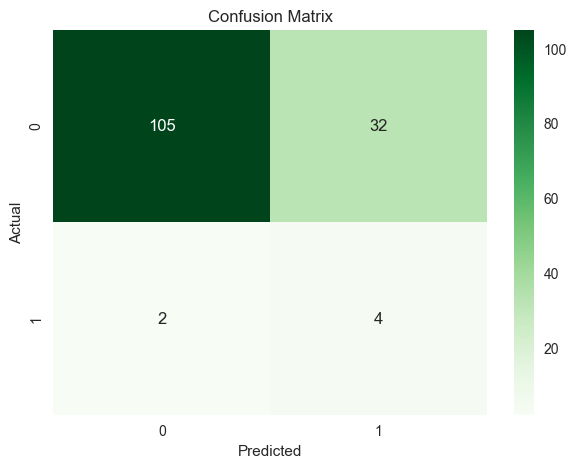

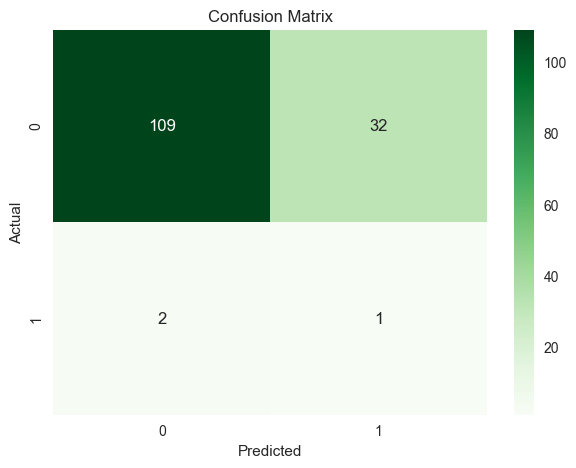

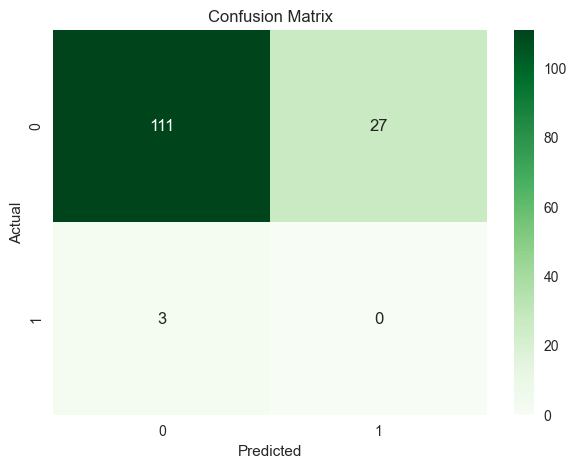

In [125]:
data_36_mid_cs = data_36_mid[mid_cs_features]
data_37_mid_cs = data_37_mid[mid_cs_features]
data_38_mid_cs = data_38_mid[mid_cs_features]
# Load model
mid_cs_model = load_model('./models/mid_cs_final_model')


data_36_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
mid_cs_preds_36 = mid_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_36['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
mid_cs_preds_37 = mid_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_37['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
mid_cs_preds_38 = mid_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_38['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Yellow cards


## GK


### Base Model


In [43]:
g_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[g_y_features]
g_y_data_tar = g_y_data_tar[g_y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


yellow_cards
0    1492
1     120
Name: count, dtype: int64


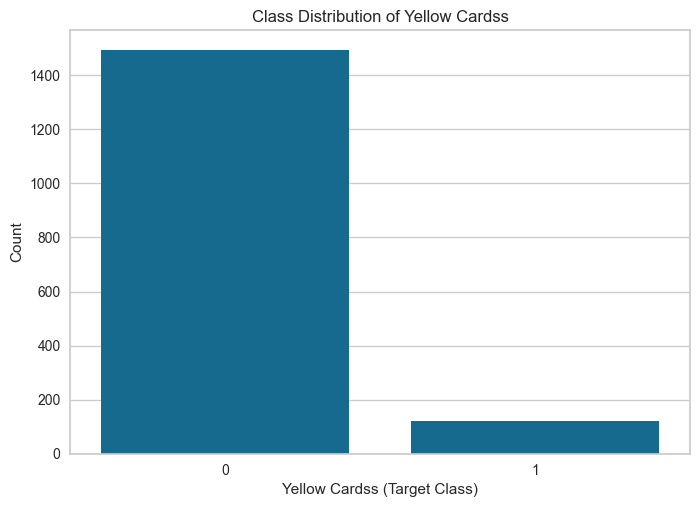

In [44]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

yellow_cards
0    1492
1     120
Name: count, dtype: int64


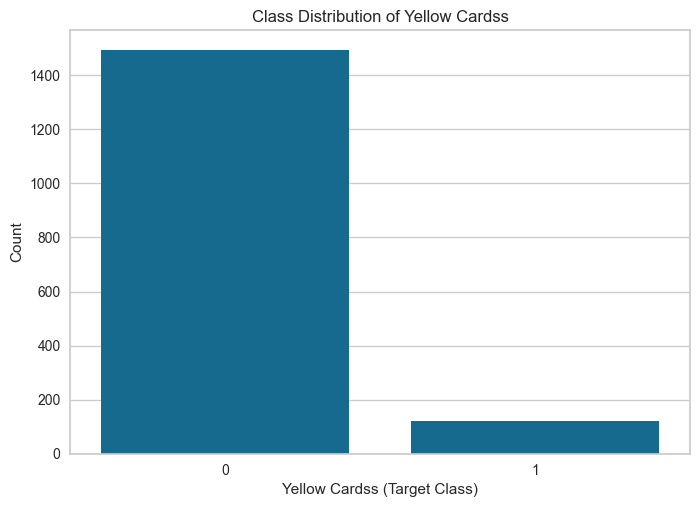

[LightGBM] [Info] Number of positive: 1193, number of negative: 1193
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12171
[LightGBM] [Info] Number of data points in the train set: 2386, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,4177
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(2709, 24)"
5,Transformed train set shape,"(2386, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.5391,0.5244,0.4689,0.0775,0.1327,0.0057,0.0078,1.1200
xgboost,Extreme Gradient Boosting,0.9185,0.5094,0.0111,0.0333,0.0167,0.0033,0.0008,1.5920
lda,Linear Discriminant Analysis,0.6144,0.5075,0.4089,0.0813,0.1355,0.0131,0.0211,1.3950
ridge,Ridge Classifier,0.6090,0.5059,0.3778,0.0738,0.1232,-0.0009,0.0015,1.1740
knn,K Neighbors Classifier,0.5392,0.5001,0.4411,0.0718,0.1233,-0.0051,-0.0071,1.2120
qda,Quadratic Discriminant Analysis,0.7680,0.5000,0.2422,0.0897,0.1296,0.0262,0.0324,1.0650
dummy,Dummy Classifier,0.9255,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9940
dt,Decision Tree Classifier,0.8255,0.4951,0.1067,0.0638,0.0796,-0.0114,-0.0110,1.0350
lightgbm,Light Gradient Boosting Machine,0.9186,0.4917,0.0000,0.0000,0.0000,-0.0118,-0.0167,1.6160
et,Extra Trees Classifier,0.9186,0.4872,0.0000,0.0000,0.0000,-0.0119,-0.0167,1.5310


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=4177, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

In [45]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_g_y_model = setup(g_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_y_best = base_g_y_model.compare_models(sort='AUC')
base_g_y_best

In [46]:
evaluate_model(base_g_y_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

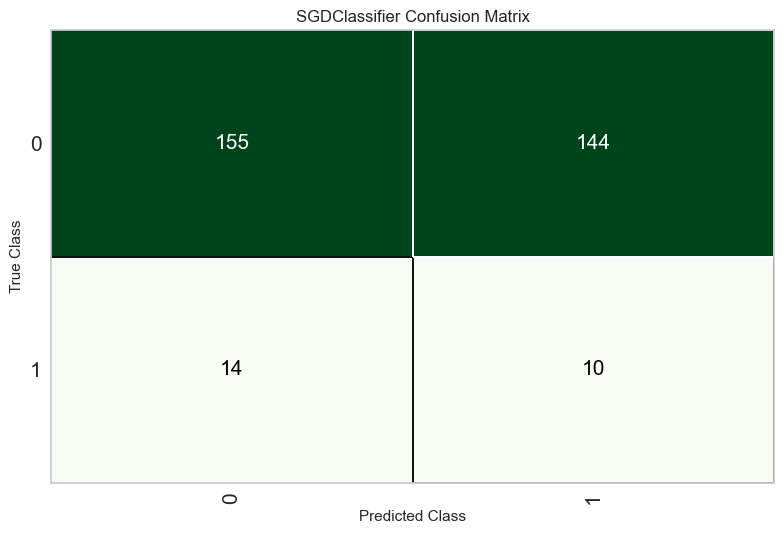

In [47]:
plot_model(base_g_y_best, plot='confusion_matrix')

### Tuned Model


In [48]:
# Enhanced setup for better performance
tuned_g_y_model = setup(g_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_y_best = tuned_g_y_model.compare_models(n_select=3, sort='F1')
g_y_best

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1106, 58)"
5,Transformed train set shape,"(697, 58)"
6,Transformed test set shape,"(323, 58)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.7176,0.5415,0.3344,0.0964,0.1487,0.0383,0.0496,0.3460
dummy,Dummy Classifier,0.0745,0.5000,1.0000,0.0745,0.1386,0.0000,0.0000,0.5050
knn,K Neighbors Classifier,0.5244,0.5069,0.4922,0.0775,0.1337,0.0058,0.0098,0.4730
nb,Naive Bayes,0.1652,0.4925,0.8600,0.0716,0.1321,-0.0062,-0.0194,0.4220
ridge,Ridge Classifier,0.6067,0.4982,0.3556,0.0709,0.1179,-0.0068,-0.0100,0.2980
xgboost,Extreme Gradient Boosting,0.8378,0.5675,0.1578,0.0972,0.1145,0.0322,0.0362,0.5680
lda,Linear Discriminant Analysis,0.6129,0.4685,0.3367,0.0686,0.1136,-0.0110,-0.0162,0.3270
lr,Logistic Regression,0.6455,0.4824,0.3067,0.0680,0.1110,-0.0112,-0.0133,0.5450
lightgbm,Light Gradient Boosting Machine,0.8557,0.5743,0.1500,0.0907,0.1110,0.0392,0.0412,1.0240
svm,SVM - Linear Kernel,0.6362,0.4960,0.2933,0.0645,0.1053,-0.0181,-0.0247,0.4180


[DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                        max_depth=None, max_features=None, max_leaf_nodes=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, random_state=123, splitter='best'),
 DummyClassifier(constant=None, random_state=123, strategy='prior'),
 KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                      metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                      weights='uniform')]

In [49]:


# Ensemble (blend or stack)
g_y_blended = blend_models(g_y_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6357,0.4912,0.2222,0.0476,0.0784,-0.0412,-0.0604
1,0.5349,0.5269,0.4444,0.0678,0.1176,-0.0039,-0.0071
2,0.6357,0.5491,0.4444,0.0870,0.1455,0.0326,0.0502
3,0.8140,0.3828,0.0000,0.0000,0.0000,-0.0994,-0.1011
4,0.6589,0.4773,0.2000,0.0526,0.0833,-0.0449,-0.0601
5,0.7209,0.5605,0.4000,0.1176,0.1818,0.0705,0.0898
6,0.6202,0.5256,0.4000,0.0851,0.1404,0.0143,0.0215
7,0.6667,0.5013,0.3000,0.0769,0.1224,-0.0011,-0.0015
8,0.6822,0.4403,0.1000,0.0303,0.0465,-0.0823,-0.1035


In [50]:

g_y_tuned = tune_model(g_y_blended, search_library='optuna', optimize='F1')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7984,0.7181,0.5556,0.1852,0.2778,0.1934,0.2331
1,0.6512,0.4625,0.1111,0.0263,0.0426,-0.0792,-0.1102
2,0.7829,0.5505,0.2222,0.0870,0.1250,0.0275,0.0314
3,0.7519,0.4613,0.3000,0.1071,0.1579,0.0493,0.0583
4,0.7519,0.3298,0.1000,0.0417,0.0588,-0.0568,-0.0641
5,0.7519,0.5273,0.1000,0.0417,0.0588,-0.0568,-0.0641
6,0.7519,0.4567,0.1000,0.0417,0.0588,-0.0568,-0.0641
7,0.7442,0.4735,0.2000,0.0741,0.1081,-0.0057,-0.0066
8,0.7209,0.4475,0.1000,0.0357,0.0526,-0.0696,-0.0823


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


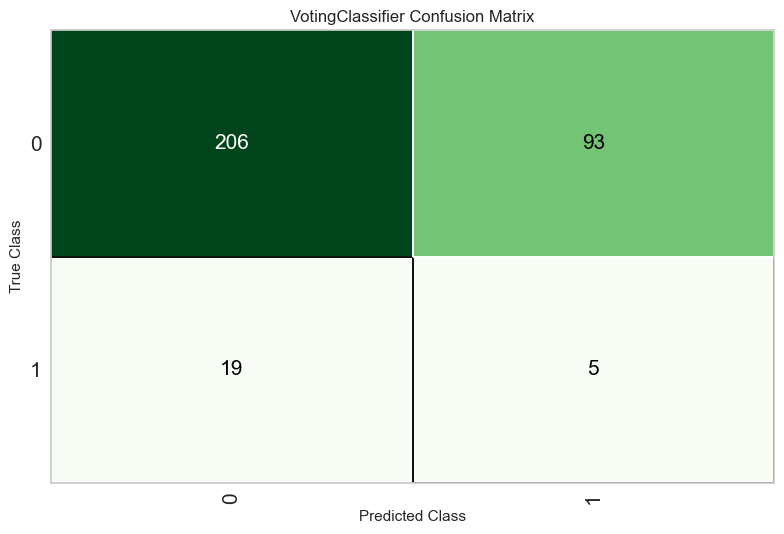

In [51]:
plot_model(g_y_tuned, plot='confusion_matrix')

In [52]:
# pcc.plot_model(tuned, plot='threshold')
preds_blend = predict_model(g_y_blended, raw_score=True)

# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_y_tuned, raw_score=True)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.6533,0.4337,0.2083,0.0510,0.0820,-0.0425,-0.0586


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.6533,0.4337,0.2083,0.0510,0.0820,-0.0425,-0.0586


In [53]:

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [54]:
evaluate_model(g_y_blended)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [55]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [56]:
g_y_final_model = finalize_model(g_y_blended)
save_model(g_y_final_model, './models/g_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                       splitter='best')),
            

### Predictions


Transformation Pipeline and Model Successfully Loaded


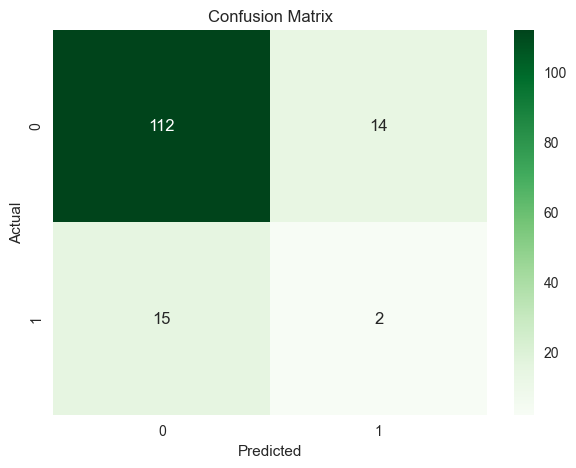

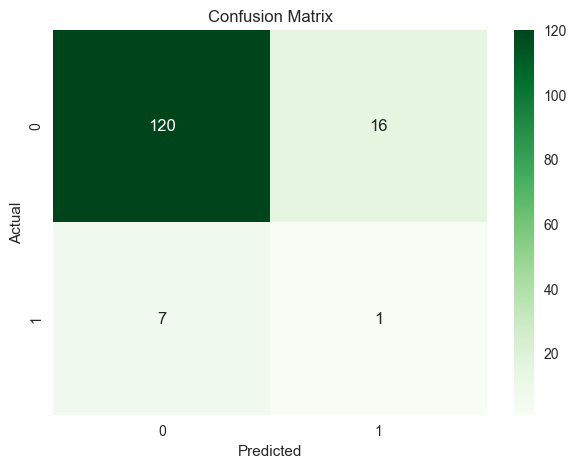

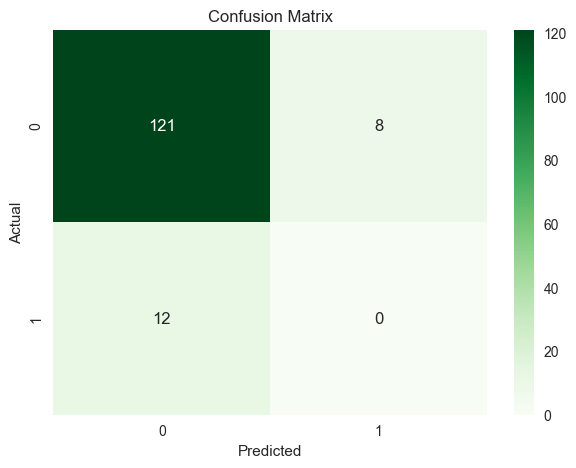

In [138]:
data_36_gk_y = data_36_mid[g_y_features]
data_37_gk_y = data_37_mid[g_y_features]
data_38_gk_y = data_38_mid[g_y_features]
# Load model
gk_y_model = load_model('./models/g_y_final_model')


data_36_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_36_gk_y[['yellow_cards']].copy()
data_36_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_36 = predict_model(gk_y_model, data=data_36_gk_y)
gk_y_preds_36 = gk_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_36['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_37_gk_y[['yellow_cards']].copy()
data_37_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_37 = predict_model(gk_y_model, data=data_37_gk_y)
gk_y_preds_37 = gk_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_37['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_38_gk_y[['yellow_cards']].copy()
data_38_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_38 = predict_model(gk_y_model, data=data_38_gk_y)
gk_y_preds_38 = gk_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_38['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Def


### Base Model


In [57]:
d_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[d_y_features]
def_y_data_tar = def_y_data_tar[d_y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

yellow_cards
0    5581
1     992
Name: count, dtype: int64


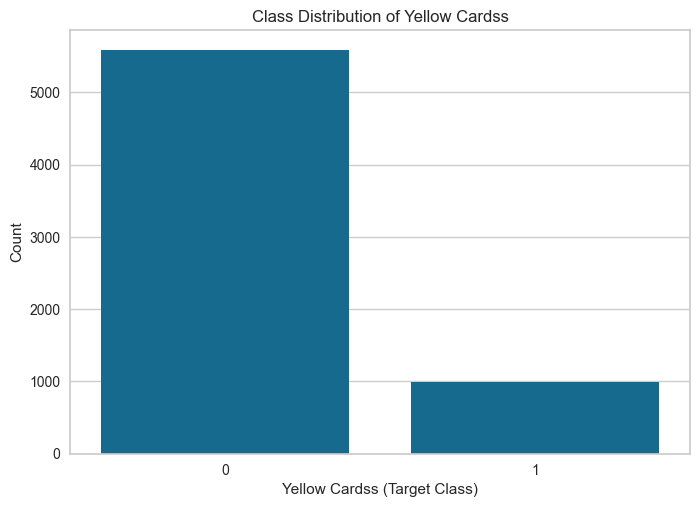

[LightGBM] [Info] Number of positive: 4464, number of negative: 4464
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17446
[LightGBM] [Info] Number of data points in the train set: 8928, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3012
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(10243, 24)"
5,Transformed train set shape,"(8928, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4669,0.5465,0.6472,0.1692,0.2682,0.0380,0.0595,4.3140
qda,Quadratic Discriminant Analysis,0.5346,0.5551,0.5579,0.1741,0.2653,0.0460,0.0634,1.8950
svm,SVM - Linear Kernel,0.4913,0.5169,0.5491,0.1599,0.2469,0.0171,0.0211,2.8120
knn,K Neighbors Classifier,0.4639,0.5250,0.5756,0.1553,0.2445,0.0090,0.0143,3.0530
ridge,Ridge Classifier,0.5046,0.5124,0.5140,0.1550,0.2381,0.0082,0.0121,1.8490
lr,Logistic Regression,0.5107,0.5059,0.4937,0.1530,0.2335,0.0039,0.0053,1.8240
lda,Linear Discriminant Analysis,0.5105,0.5087,0.4673,0.1470,0.2235,-0.0078,-0.0105,1.8290
dt,Decision Tree Classifier,0.7128,0.5031,0.2026,0.1549,0.1753,0.0054,0.0055,2.1970
xgboost,Extreme Gradient Boosting,0.8364,0.5457,0.0403,0.2490,0.0690,0.0279,0.0427,2.4180
ada,Ada Boost Classifier,0.8248,0.5512,0.0352,0.1818,0.0577,0.0023,0.0082,2.7300


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4658,0.5358,0.5949,0.1588,0.2507,0.0178,0.0273
1,0.4525,0.5304,0.6329,0.1618,0.2577,0.0243,0.0388
2,0.4506,0.5620,0.6709,0.1677,0.2684,0.0369,0.0602
3,0.4943,0.5222,0.5823,0.1649,0.2570,0.0299,0.0437
4,0.4791,0.5606,0.5875,0.1632,0.2554,0.0228,0.0340
5,0.4715,0.5586,0.6500,0.1722,0.2723,0.0418,0.0650
6,0.4753,0.5707,0.6875,0.1797,0.2850,0.0578,0.0908
7,0.4867,0.5544,0.6250,0.1724,0.2703,0.0418,0.0627
8,0.4781,0.5486,0.6076,0.1649,0.2595,0.0298,0.0451


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [58]:
print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_def_y_model = setup(def_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_y_best = base_def_y_model.compare_models(sort='F1')
base_def_y_best

print('Tuning the model...')
def_y_base_tuned = tune_model(base_def_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

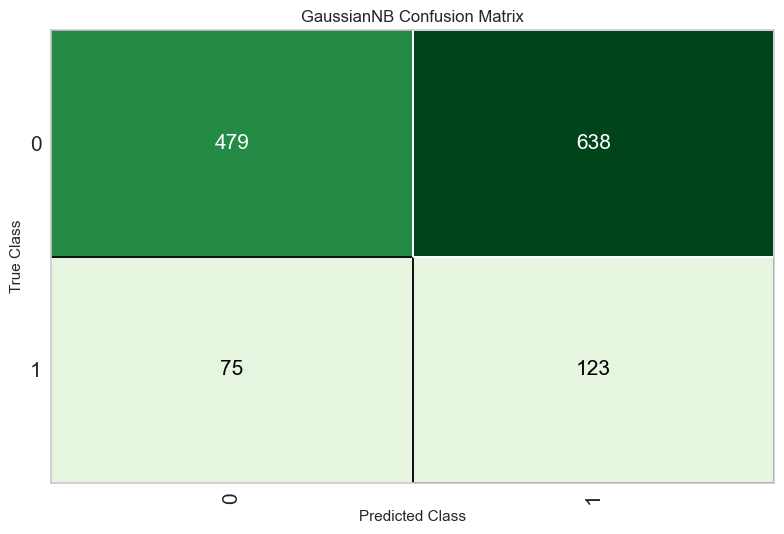

In [59]:
evaluate_model(base_def_y_best)
plot_model(base_def_y_best, plot='confusion_matrix')

### Blended Model


In [60]:
# Enhanced setup for better performance
tuned_def_y_model = setup(def_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_y_best = tuned_def_y_model.compare_models(n_select=3, sort='F1')
print(def_y_best)

print('Blended model')
# Ensemble (blend or stack)
def_y_blended = blend_models(def_y_best, optimize='F1')

def_y_tuned = tune_model(def_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(5125, 65)"
5,Transformed train set shape,"(3692, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.1510,0.5000,1.0000,0.1510,0.2624,0.0000,0.0000,0.6980
lda,Linear Discriminant Analysis,0.3336,0.5098,0.7746,0.1560,0.2597,0.0112,0.0251,0.7910
knn,K Neighbors Classifier,0.3286,0.5210,0.7732,0.1548,0.2580,0.0086,0.0192,0.8080
lr,Logistic Regression,0.3300,0.5140,0.7583,0.1530,0.2546,0.0045,0.0101,0.7640
nb,Naive Bayes,0.4815,0.5332,0.5856,0.1624,0.2542,0.0234,0.0351,0.7610
ridge,Ridge Classifier,0.3049,0.5057,0.7795,0.1509,0.2529,-0.0001,0.0002,0.7710
svm,SVM - Linear Kernel,0.4015,0.4996,0.6409,0.1512,0.2445,0.0004,-0.0006,0.8150
dt,Decision Tree Classifier,0.6400,0.5109,0.3260,0.1614,0.2150,0.0165,0.0176,0.9110
ada,Ada Boost Classifier,0.6687,0.5387,0.2922,0.1645,0.2101,0.0212,0.0226,1.3110
et,Extra Trees Classifier,0.7239,0.5445,0.2404,0.1841,0.2078,0.0447,0.0454,1.1930


[DummyClassifier(constant=None, random_state=123, strategy='prior'), LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001), KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2414,0.5256,0.8861,0.1522,0.2597,0.0046,0.0147
1,0.2224,0.5177,0.8608,0.1459,0.2495,-0.0098,-0.0333
2,0.2433,0.5074,0.8481,0.1479,0.2519,-0.0052,-0.0159
3,0.2414,0.4931,0.8608,0.1491,0.2542,-0.0024,-0.0076
4,0.2510,0.5487,0.9375,0.1616,0.2757,0.0220,0.0727
5,0.2224,0.4939,0.8625,0.1478,0.2523,-0.0100,-0.0340
6,0.2224,0.5449,0.9000,0.1522,0.2604,0.0003,0.0011
7,0.2490,0.4867,0.8750,0.1538,0.2617,0.0040,0.0124
8,0.2381,0.5591,0.8987,0.1533,0.2620,0.0066,0.0219


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3555,0.5148,0.8228,0.1667,0.2772,0.0365,0.0781
1,0.3023,0.4609,0.7468,0.1453,0.2433,-0.0109,-0.0251
2,0.3099,0.4725,0.7215,0.1432,0.2390,-0.0155,-0.0344
3,0.3289,0.4808,0.7215,0.1469,0.2441,-0.0073,-0.0154
4,0.3137,0.5794,0.8125,0.1582,0.2648,0.0136,0.0319
5,0.2985,0.4805,0.7625,0.1484,0.2485,-0.0082,-0.0193
6,0.3460,0.5949,0.8500,0.1700,0.2833,0.0400,0.0889
7,0.2947,0.4549,0.7500,0.1460,0.2444,-0.0137,-0.0321
8,0.3333,0.5676,0.8734,0.1687,0.2828,0.0409,0.0957


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [61]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
def_y_final_model = finalize_model(base_g_y_best)
save_model(def_y_final_model, './models/def_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  SGDClassifier(alpha=0.0001, average=False, class_weight=None,
                      

### Predicitions


Transformation Pipeline and Model Successfully Loaded


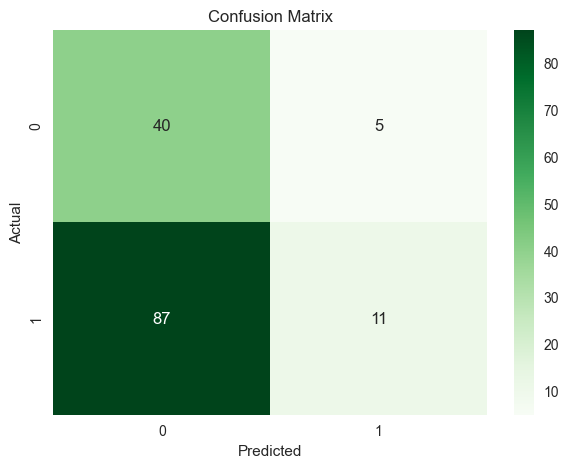

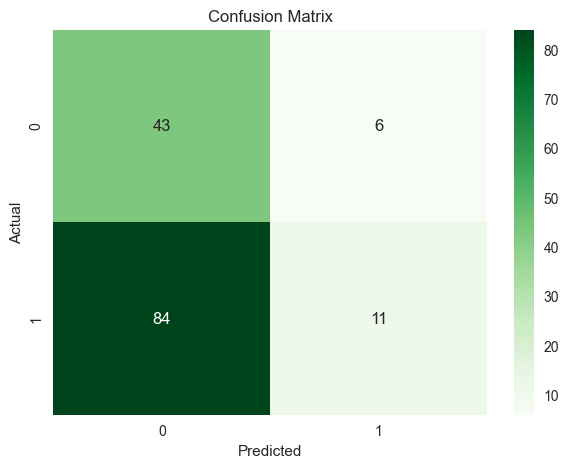

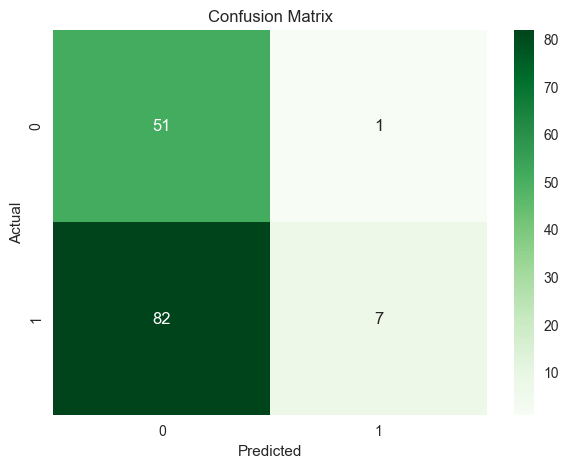

In [137]:
data_36_def_y = data_36_mid[d_y_features]
data_37_def_y = data_37_mid[d_y_features]
data_38_def_y = data_38_mid[d_y_features]
# Load model
def_y_model = load_model('./models/def_y_final_model')


data_36_def_y.reset_index(drop=True, inplace=True)
def_y = data_36_def_y[['yellow_cards']].copy()
data_36_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_36 = predict_model(def_y_model, data=data_36_def_y)
def_y_preds_36 = def_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_36['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_def_y.reset_index(drop=True, inplace=True)
def_y = data_37_def_y[['yellow_cards']].copy()
data_37_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_37 = predict_model(def_y_model, data=data_37_def_y)
def_y_preds_37 = def_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_37['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_def_y.reset_index(drop=True, inplace=True)
def_y = data_38_def_y[['yellow_cards']].copy()
data_38_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_38 = predict_model(def_y_model, data=data_38_def_y)
def_y_preds_38 = def_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_38['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Mid


In [62]:
mid_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[mid_y_features]
mid_y_data_tar = mid_y_data_tar[mid_y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


### Base Model


yellow_cards
0    5970
1    1106
Name: count, dtype: int64


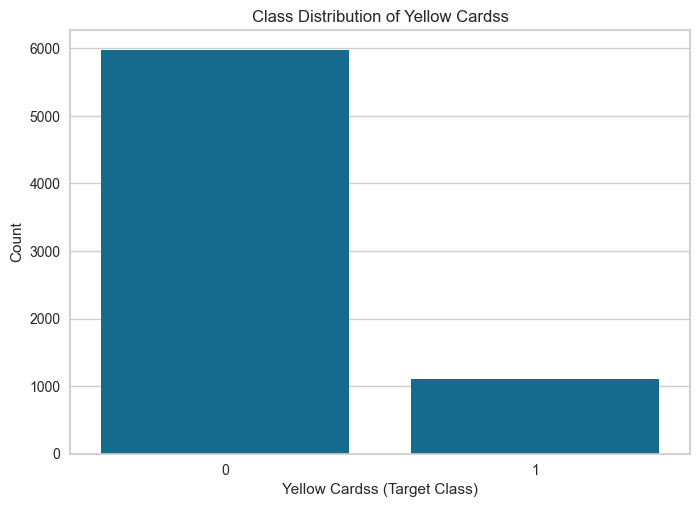

[LightGBM] [Info] Number of positive: 4775, number of negative: 4775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16969
[LightGBM] [Info] Number of data points in the train set: 9550, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,8768
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 116)"
4,Transformed data shape,"(10966, 24)"
5,Transformed train set shape,"(9550, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,114
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5746,0.5998,0.5751,0.2002,0.2969,0.0847,0.1093,1.8480
lr,Logistic Regression,0.5585,0.5899,0.5706,0.1923,0.2875,0.0702,0.0924,2.1480
ridge,Ridge Classifier,0.5652,0.5906,0.5615,0.1931,0.2873,0.0714,0.0929,1.9180
svm,SVM - Linear Kernel,0.5403,0.5744,0.5911,0.1896,0.2864,0.0656,0.0891,2.1850
nb,Naive Bayes,0.4525,0.5795,0.6950,0.1786,0.2840,0.0471,0.0764,1.7050
qda,Quadratic Discriminant Analysis,0.5385,0.5713,0.5695,0.1843,0.2784,0.0553,0.0744,1.8290
knn,K Neighbors Classifier,0.4760,0.5508,0.6396,0.1762,0.2763,0.0412,0.0625,1.5910
dt,Decision Tree Classifier,0.7064,0.5111,0.2270,0.1698,0.1940,0.0191,0.0195,2.4210
et,Extra Trees Classifier,0.8258,0.5821,0.0553,0.2446,0.0886,0.0344,0.0462,2.4370
xgboost,Extreme Gradient Boosting,0.8231,0.5671,0.0507,0.2012,0.0805,0.0238,0.0287,2.4330


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5742,0.6329,0.5682,0.1976,0.2933,0.0813,0.1046
1,0.5760,0.5804,0.4659,0.1752,0.2547,0.0371,0.0457
2,0.5795,0.5829,0.4886,0.1822,0.2654,0.0503,0.0624
3,0.5707,0.6052,0.5909,0.2008,0.2997,0.0881,0.1148
4,0.5954,0.6059,0.5682,0.2075,0.3040,0.0986,0.1236
5,0.5689,0.6135,0.6292,0.2097,0.3146,0.1030,0.1363
6,0.5742,0.5915,0.5618,0.1984,0.2933,0.0793,0.1013
7,0.5512,0.5864,0.5955,0.1956,0.2944,0.0756,0.1009
8,0.5565,0.5792,0.5618,0.1908,0.2849,0.0655,0.0857


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [63]:
print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_mid_y_model = setup(mid_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_y_best = base_mid_y_model.compare_models(sort='F1')
base_mid_y_best

print('Tuning the model...')
mid_y_base_tuned = tune_model(base_mid_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

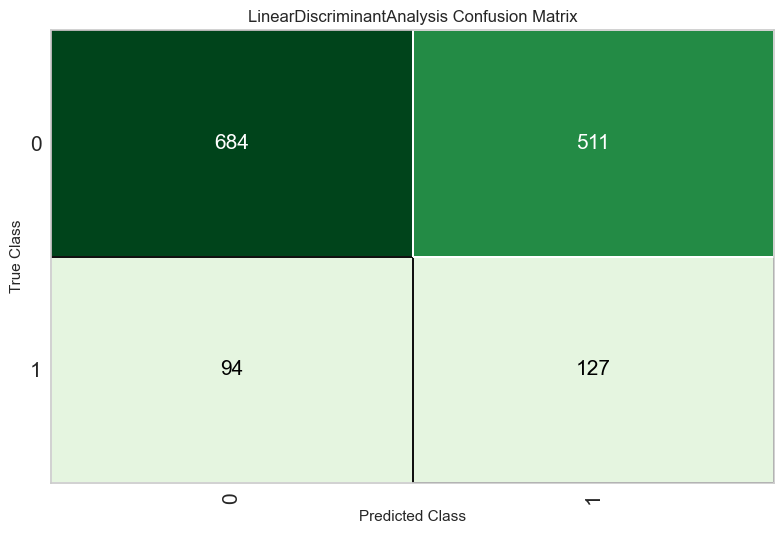

In [64]:
evaluate_model(base_mid_y_best)
plot_model(base_mid_y_best, plot='confusion_matrix')

### Blended Model


In [65]:
# Convert all boolean columns to int to avoid numpy WRITEABLE flag error
for col in mid_y_data.select_dtypes(include='bool').columns:
    mid_y_data[col] = mid_y_data[col].astype(int)

# Enhanced setup for better performance
tuned_mid_y_model = setup(mid_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_y_best = tuned_mid_y_model.compare_models( sort='F1')
print(mid_y_best)

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 116)"
4,Transformed data shape,"(6203, 67)"
5,Transformed train set shape,"(4888, 67)"
6,Transformed test set shape,"(1416, 67)"
7,Numeric features,115
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.4193,0.5950,0.7751,0.1818,0.2945,0.0552,0.0990,0.8260
lda,Linear Discriminant Analysis,0.4219,0.5942,0.7582,0.1799,0.2908,0.0510,0.0904,0.7940
svm,SVM - Linear Kernel,0.4534,0.5751,0.7084,0.1814,0.2885,0.0528,0.0856,0.8730
ridge,Ridge Classifier,0.4009,0.5915,0.7672,0.1759,0.2861,0.0425,0.0781,0.9340
knn,K Neighbors Classifier,0.3203,0.5492,0.8249,0.1651,0.2752,0.0197,0.0451,0.8380
dummy,Dummy Classifier,0.1564,0.5000,1.0000,0.1564,0.2704,0.0000,0.0000,0.8330
nb,Naive Bayes,0.5413,0.5765,0.5639,0.1855,0.2630,0.0533,0.0754,0.9000
ada,Ada Boost Classifier,0.6737,0.5702,0.3478,0.1967,0.2507,0.0633,0.0672,1.5400
et,Extra Trees Classifier,0.7251,0.5895,0.2926,0.2180,0.2493,0.0858,0.0873,1.2130
dt,Decision Tree Classifier,0.6420,0.5310,0.3694,0.1823,0.2439,0.0438,0.0485,1.0020


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


### Save Model


In [66]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
mid_y_final_model = finalize_model(mid_y_best)
save_model(mid_y_final_model, './models/mid_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha', 'was_home',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', '...
                  TransformerWrapper(exclude=None, include=None,
                                    

### Predictions


Transformation Pipeline and Model Successfully Loaded


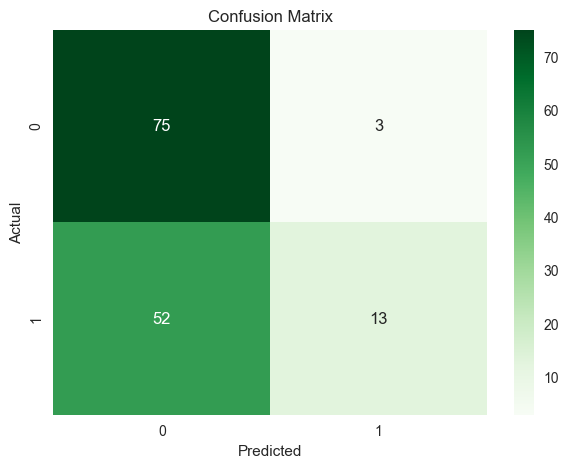

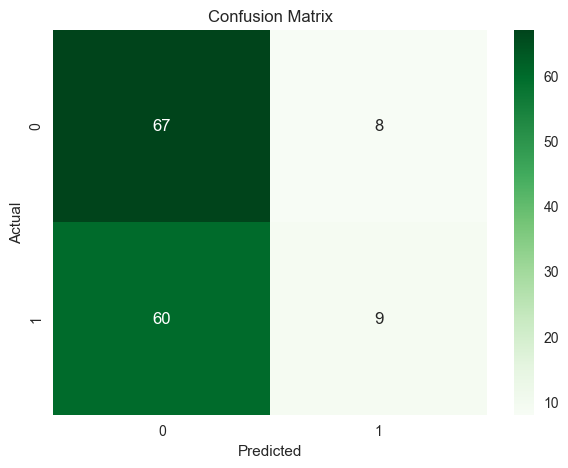

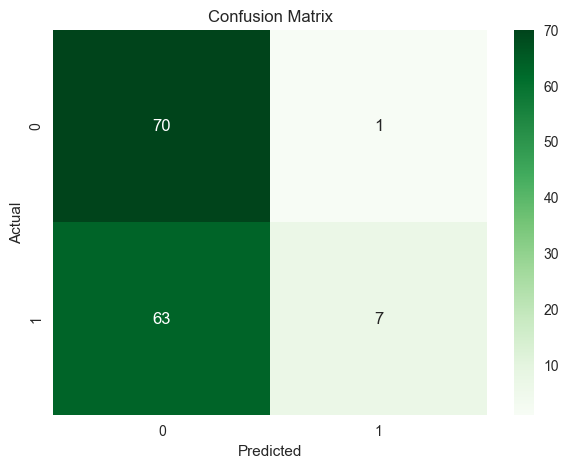

In [136]:
data_36_mid_y = data_36_mid[mid_y_features]
data_37_mid_y = data_37_mid[mid_y_features]
data_38_mid_y = data_38_mid[mid_y_features]
# Load model
mid_y_model = load_model('./models/mid_y_final_model')


data_36_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_36_mid_y[['yellow_cards']].copy()
data_36_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_36 = predict_model(mid_y_model, data=data_36_mid_y)
mid_y_preds_36 = mid_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_36['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_37_mid_y[['yellow_cards']].copy()
data_37_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_37 = predict_model(mid_y_model, data=data_37_mid_y)
mid_y_preds_37 = mid_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_37['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_38_mid_y[['yellow_cards']].copy()
data_38_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_38 = predict_model(mid_y_model, data=data_38_mid_y)
mid_y_preds_38 = mid_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_38['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## FWD


In [67]:
fwd_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home',  'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[fwd_y_features]
fwd_y_data_tar = fwd_y_data_tar[fwd_y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

### Base Model


yellow_cards
0    1402
1     188
Name: count, dtype: int64


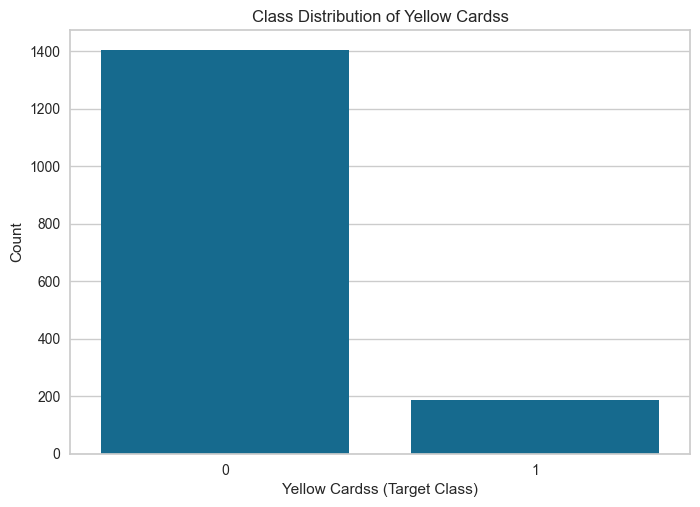

[LightGBM] [Info] Number of positive: 1122, number of negative: 1122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17006
[LightGBM] [Info] Number of data points in the train set: 2244, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3118
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 116)"
4,Transformed data shape,"(2562, 24)"
5,Transformed train set shape,"(2244, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.6117,0.5913,0.5200,0.1556,0.2381,0.0704,0.0956,1.1010
lr,Logistic Regression,0.6031,0.5526,0.4933,0.1477,0.2270,0.0557,0.0737,1.2340
ridge,Ridge Classifier,0.6006,0.5724,0.5000,0.1463,0.2262,0.0543,0.0746,1.0840
nb,Naive Bayes,0.5173,0.5163,0.5533,0.1307,0.2111,0.0259,0.0430,1.3520
knn,K Neighbors Classifier,0.4693,0.5073,0.5800,0.1242,0.2044,0.0129,0.0226,1.2010
svm,SVM - Linear Kernel,0.5165,0.5362,0.5067,0.1235,0.1981,0.0108,0.0162,1.1860
dt,Decision Tree Classifier,0.7515,0.5184,0.2133,0.1414,0.1689,0.0313,0.0321,1.2240
qda,Quadratic Discriminant Analysis,0.6879,0.4953,0.2533,0.1208,0.1627,0.0028,0.0014,1.1270
ada,Ada Boost Classifier,0.8121,0.5168,0.1467,0.1674,0.1547,0.0507,0.0511,1.3080
rf,Random Forest Classifier,0.8624,0.5270,0.0600,0.1917,0.0897,0.0417,0.0507,1.8080


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5703,0.5156,0.4000,0.1154,0.1791,-0.0034,-0.0046
1,0.5625,0.5068,0.4667,0.1273,0.2000,0.0194,0.0272
2,0.6220,0.5845,0.6000,0.1765,0.2727,0.1103,0.1481
3,0.6693,0.6696,0.6667,0.2128,0.3226,0.1748,0.2248
4,0.6614,0.6792,0.6000,0.1957,0.2951,0.1423,0.1811
5,0.6063,0.5083,0.3333,0.1111,0.1667,-0.0128,-0.0161
6,0.6220,0.5982,0.6667,0.1887,0.2941,0.1348,0.1850
7,0.5827,0.4488,0.2667,0.0870,0.1311,-0.0572,-0.0727
8,0.5591,0.5702,0.6000,0.1525,0.2432,0.0676,0.0994


In [68]:
print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_fwd_y_model = setup(fwd_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_fwd_y_best = base_fwd_y_model.compare_models(sort='F1')
base_fwd_y_best

print('Tuning the model...')
fwd_y_base_tuned = tune_model(base_fwd_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

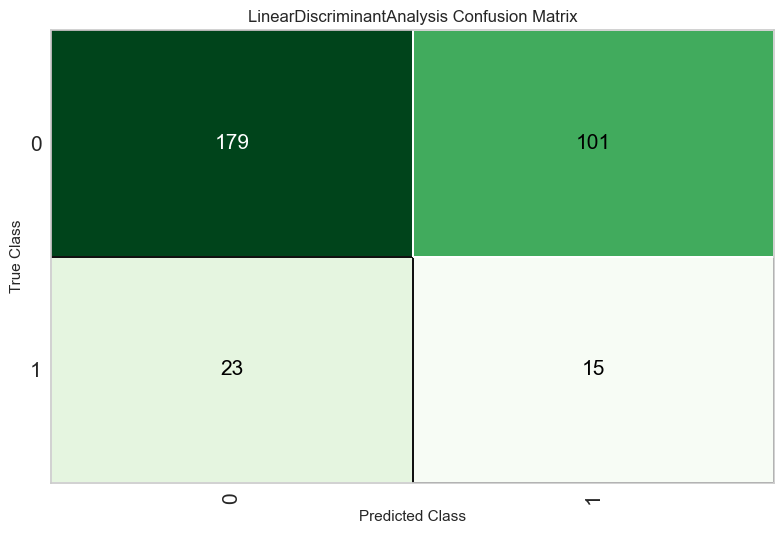

In [69]:
evaluate_model(base_fwd_y_best)
plot_model(base_fwd_y_best, plot='confusion_matrix')

### Blended Model


In [70]:
# Enhanced setup for better performance
tuned_fwd_y_model = setup(fwd_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

fwd_y_best = tuned_fwd_y_model.compare_models(n_select=3, sort='F1')
print(fwd_y_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_y_blended = blend_models(fwd_y_best, optimize='F1')

fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 116)"
4,Transformed data shape,"(1105, 64)"
5,Transformed train set shape,"(787, 64)"
6,Transformed test set shape,"(318, 64)"
7,Numeric features,114
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.3931,0.5344,0.7333,0.1308,0.2219,0.0272,0.0556,0.3790
dummy,Dummy Classifier,0.1179,0.5000,1.0000,0.1179,0.2110,0.0000,0.0000,0.3340
lda,Linear Discriminant Analysis,0.5590,0.5180,0.4667,0.1270,0.1994,0.0174,0.0248,0.3260
svm,SVM - Linear Kernel,0.5795,0.5053,0.4400,0.1279,0.1977,0.0189,0.0251,0.3060
ridge,Ridge Classifier,0.5550,0.5220,0.4667,0.1253,0.1971,0.0146,0.0219,0.3610
lr,Logistic Regression,0.5684,0.4914,0.4000,0.1153,0.1789,-0.0048,-0.0061,0.3930
ada,Ada Boost Classifier,0.7492,0.4821,0.1800,0.1310,0.1494,0.0113,0.0099,0.5360
dt,Decision Tree Classifier,0.7171,0.4873,0.1867,0.1088,0.1369,-0.0155,-0.0180,0.3790
nb,Naive Bayes,0.5180,0.4989,0.4933,0.1726,0.1356,0.0104,0.0334,0.3630
qda,Quadratic Discriminant Analysis,0.6153,0.5339,0.3467,0.1856,0.1327,-0.0020,-0.0086,0.3690


[KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform'), DummyClassifier(constant=None, random_state=123, strategy='prior'), LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4531,0.5858,0.6667,0.1333,0.2222,0.0334,0.0597
1,0.3828,0.3953,0.4000,0.0789,0.1319,-0.0794,-0.1437
2,0.4016,0.5560,0.7333,0.1325,0.2245,0.0305,0.0614
3,0.3937,0.6625,0.7333,0.1310,0.2222,0.0273,0.0556
4,0.4252,0.6256,0.8000,0.1463,0.2474,0.0596,0.1181
5,0.3780,0.5536,0.6000,0.1098,0.1856,-0.0176,-0.0349
6,0.5039,0.5857,0.6667,0.1471,0.2410,0.0588,0.0963
7,0.4646,0.4214,0.4000,0.0923,0.1500,-0.0519,-0.0819
8,0.3465,0.4006,0.6667,0.1136,0.1942,-0.0096,-0.0208


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4922,0.4932,0.6000,0.1324,0.2169,0.0308,0.0502
1,0.3906,0.3156,0.3333,0.0685,0.1136,-0.1003,-0.1744
2,0.4488,0.5214,0.4667,0.1014,0.1667,-0.0340,-0.0563
3,0.5118,0.6661,0.6667,0.1493,0.2439,0.0631,0.1020
4,0.4567,0.6030,0.6667,0.1351,0.2247,0.0352,0.0623
5,0.4567,0.5333,0.6000,0.1250,0.2069,0.0142,0.0244
6,0.5039,0.5440,0.4667,0.1129,0.1818,-0.0104,-0.0158
7,0.5748,0.5470,0.6000,0.1579,0.2500,0.0775,0.1112
8,0.5197,0.4012,0.2667,0.0741,0.1159,-0.0846,-0.1174


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [71]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
fwd_y_final_model = finalize_model(base_fwd_y_best)
save_model(fwd_y_final_model, './models/fwd_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                  random_state=None,
 

### Predicitions


Transformation Pipeline and Model Successfully Loaded


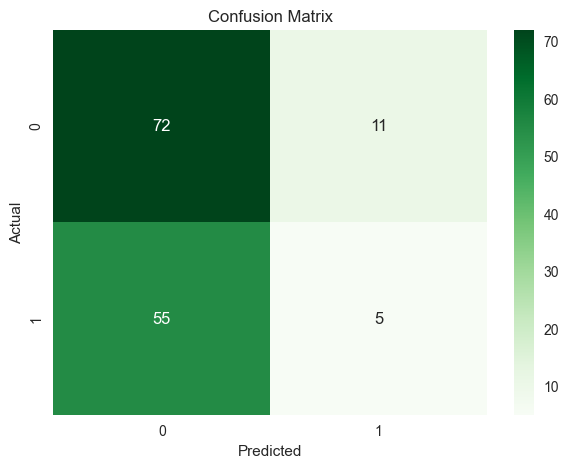

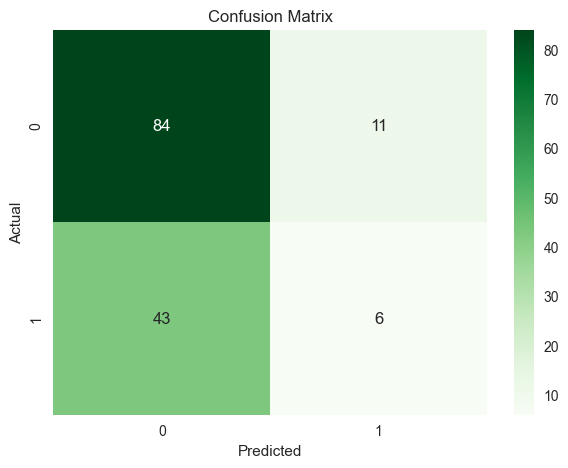

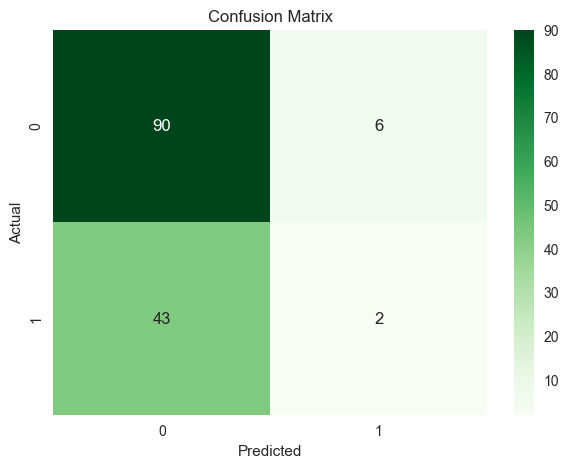

In [139]:
data_36_fwd_y = data_36_mid[fwd_y_features]
data_37_fwd_y = data_37_mid[fwd_y_features]
data_38_fwd_y = data_38_mid[fwd_y_features]
# Load model
fwd_y_model = load_model('./models/fwd_y_final_model')


data_36_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_36_fwd_y[['yellow_cards']].copy()
data_36_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_36 = predict_model(fwd_y_model, data=data_36_fwd_y)
fwd_y_preds_36 = fwd_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_36['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_37_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_37_fwd_y[['yellow_cards']].copy()
data_37_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_37 = predict_model(fwd_y_model, data=data_37_fwd_y)
fwd_y_preds_37 = fwd_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_37['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


data_38_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_38_fwd_y[['yellow_cards']].copy()
data_38_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_38 = predict_model(fwd_y_model, data=data_38_fwd_y)
fwd_y_preds_38 = fwd_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_38['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()